In [1]:
from pydantic import BaseModel , Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages

from typing import Literal, Dict , Any, Annotated, List
from IPython.display import Image, display 
import instructor
from operator import add

import random
import ast
import inspect
import json

from openai import OpenAI
from jinja2 import Template

from utils.utils import get_tool_descriptions, format_ai_message

from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PointStruct, PayloadSchemaType, SparseVectorParams, Document, Prefetch, FusionQuery
from qdrant_client import models


from api.agents.local_models import CHAT_MODEL , EMBED_MODEL



/home/nurda/ai-engineering/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
from openai import OpenAI

client_local = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",  
)

In [3]:
qdrant_client = QdrantClient(url="http://localhost:6333")

/home/nurda/ai-engineering/.venv/lib/python3.12/site-packages/qdrant_client/qdrant_remote.py:288: UserWarning: Failed to obtain server version. Unable to check client-server compatibility. Set check_compatibility=False to skip version check.
  show_warning(


In [4]:
def get_embedding(text, model="nomic-embed-text"):
    safe_text = text[:10000]
    response = client_local.embeddings.create(
        input=safe_text,
        model=model
    )
    return response.data[0].embedding

In [5]:
def retrieve_data(query, qdrant_client, top_k=5):
    query_embedding = get_embedding(query)
    search_result = qdrant_client.query_points(
        collection_name="Amazon_items_collection1_hybrid_search",
        prefetch = [
            Prefetch(
             query=query_embedding,
             using="nomic-embed-text",
             limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm-25",
                limit=20
                )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=top_k
    )

    retrieved_context_ids = []
    retrieved_contexts = []
    similarity_scores = []
    retrieved_context_ratings = []

    for point in search_result.points:
        retrieved_context_ids.append(point.payload["parent_asin"])
        retrieved_contexts.append(point.payload["description"])
        retrieved_context_ratings.append(point.payload["average_rating"])
        similarity_scores.append(point.score)

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_contexts": retrieved_contexts,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

In [7]:
query = "What are some good products for listening to music?"
retrieved_data = retrieve_data(query, qdrant_client, top_k=10)
print(retrieved_data)   

{'retrieved_context_ids': ['B0C7CBZKFB', 'B0BBMSYX16', 'B0C1BYWJ5Y', 'B0BBMSYX16', 'B0C7CBZKFB', 'B0C1BYWJ5Y', 'B09Y4HCRLM', 'B0BF9DQB6K', 'B09Y4HCRLM', 'B08QS12HXF'], 'retrieved_contexts': ["Dsrva Bone Conduction Swimming Headphones IP68 Waterproof Bluetooth V5.2 Built-in 32GB MP3 Sports Ultra Light Headphones for Swimming Running 【Revolutionary Bone Conduction Technology】: Enjoy crystal-clear sound without hurting your ears. Perfect for exercise, driving, gaming, and phone conversations. 【Open-Ear Comfort】: Stay connected to your surroundings while enjoying your music. Lightweight and comfortable for all-day wear, even with glasses or under a helmet. 【Long-Lasting Battery Life and Noise-Cancelling Calls】: Enjoy up to 8 hours of playtime and clear calls with noise-cancelling technology. Perfect for podcasts, sports, and more. 【Designed for Swimmers】: Fully waterproof and submersible with an IP68 rating. Internal 32GB storage for up to 8000 songs. Enjoy device-free listening while you 

## Multi intent Question

In [8]:
query = "Can I get tablets for me, for my kids and for my wife?"

In [9]:
retrieved_data = retrieve_data(query, qdrant_client, top_k=10)


In [10]:
retrieved_data

{'retrieved_context_ids': ['B08FFYP2BF',
  'B09S3LKTK7',
  'B0B1X471HB',
  'B08FFYP2BF',
  'B09S3LKTK7',
  'B0B1X471HB',
  'B09YNHX8F7',
  'B0BW97CJXM',
  'B09YNHX8F7',
  'B0BW97CJXM'],
 'retrieved_contexts': ["Xboun Kids Case for iPad Mini 5 4 3 2 (Old Model，7.9In) - Car Wheel Series EVA Shock Proof Handle Friendly Convertible Stand Case for iPad Mini 5 (2019) Generation, Mini 3rd Tablet (Rose-Car) 🍎【𝘾𝙤𝙢𝙥𝙖𝙩𝙞𝙗𝙞𝙡𝙞𝙩𝙮 】Designed exclusively for Apple iPad Mini, Mini 2, Mini 3，iPad mini 4 and iPad mini 5th Generation 2019 only. ( NOT Fit iPad 4/3/2/Air/Air 2 NOR iPad Pro 9.7/ iPad 9.7 2018 and any other tablets ) 🍎【𝟯𝟲𝟬° 𝙎𝙝𝙤𝙘𝙠𝙥𝙧𝙤𝙤𝙛】iPad Mini Case for Kids - Made of Non-toxic EVA foam rubber material, kids-proof and environmental, it will not be harmful to child's health. Durable and heavy duty soft foam is shock-resistant bumps, and scratches from damaging. 🍎【𝙒𝙞𝙣𝙜𝙨 𝙎𝙩𝙖𝙣𝙙】 Unique Beetle design make the case lovely and attractive, the wings can be used as kickstand, the antenna usaully as carr

Handling multi-intent questions is one of the most common bottlenecks in Retrieval-Augmented Generation. When a user asks something like, "How do I configure the server, and what are the default timeout settings?", standard RAG pipelines often fail.

The core issue is the embedding bottleneck. Squashing two distinct, unrelated concepts into a single vector—especially a compact 768-dimension embedding like those generated by mxbai-embed-large—often dilutes the semantic signal. The resulting vector ends up floating somewhere between the two concepts in the vector space, leading to poor retrieval for both intents.

Here are the standard architectural patterns to resolve this:

1. Query Decomposition (Sub-Query Generation)
Instead of embedding the raw user prompt, intercept it and use an LLM to split it into distinct, single-intent questions.

Original: "Compare the installation steps for Windows and the memory usage on Linux."

Decomposed: 1. "What are the installation steps for Windows?"
2. "What is the memory usage on Linux?"

You can handle this by passing the initial prompt to a fast, lightweight local model before hitting your retrieval logic.

2. Parallel Retrieval
Once you have the decomposed queries, embed each one separately. Run parallel searches against your Qdrant database for each generated embedding. This ensures you pull the most relevant chunks for every intent, rather than a compromised set of chunks that sort-of matches the whole prompt.

3. Context Deduplication and Aggregation
Parallel retrieval will likely return overlapping documents.

Merge: Combine the retrieved chunks from all sub-queries.

Deduplicate: Filter out identical chunks based on their payload IDs or text content to save context window space.

Rank (Optional): Use a cross-encoder or a reranker to score the merged chunks against the original, multi-intent prompt to ensure the most critical information floats to the top.

4. Semantic Routing (If Intents Span Different Domains)
Sometimes a multi-intent query requires hitting entirely different databases or APIs. A semantic router classifies the intents of the prompt and directs the flow accordingly. For example, intent A might require a vector search in Qdrant, while intent B might trigger an API call or an SQL query.

### Query decomposition and rewriting

In [11]:
class QueryExpandResponse(BaseModel):
    queries: List[str]

In [22]:
def query_expand_node(query) -> dict:

    prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.

<Question>
{{ query }}
</Question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=query
    )


    client = instructor.from_openai(client_local)

    response, raw_response = client.chat.completions.create_with_completion(
        model=CHAT_MODEL,
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )

    return {
        "queries": response
    }

In [23]:
result = query_expand_node(query)

In [24]:
result

{'queries': QueryExpandResponse(queries=['tablets for adults', 'tablets for children', 'tablets for women'])}

## Langgraph

### Query expansion (sequential execution)

In [25]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context : Annotated[List[str], add] = []
    initial_query: str = ""
    answer : str = ""

In [27]:
### query expansion/ rewriting node

class QueryExpandResponse(BaseModel):
    expanded_query: List[str]

In [28]:
def query_expand_node(state: State) -> dict:

    prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.

<Question>
{{ query }}
</Question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )


    client = instructor.from_openai(client_local)

    response, raw_response = client.chat.completions.create_with_completion(
        model=CHAT_MODEL,
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )

    return {
        "expanded_query": response.expanded_query
    }

#### Retriever node

In [29]:
def get_embedding(text, model="nomic-embed-text"):
    safe_text = text[:10000]
    response = client_local.embeddings.create(
        input=safe_text,
        model=model
    )
    return response.data[0].embedding

In [39]:
def retrieve_data(query, qdrant_client, top_k=5):
    query_embedding = get_embedding(query)
    search_result = qdrant_client.query_points(
        collection_name="Amazon_items_collection1_hybrid_search",
        prefetch = [
            Prefetch(
             query=query_embedding,
             using="nomic-embed-text",
             limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm-25",
                limit=20
                )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=top_k
    )

    retrieved_context_ids = []
    retrieved_contexts = []
    similarity_scores = []
    retrieved_context_ratings = []

    for point in search_result.points:
        retrieved_context_ids.append(point.payload["parent_asin"])
        retrieved_contexts.append(point.payload["description"])
        retrieved_context_ratings.append(point.payload["average_rating"])
        similarity_scores.append(point.score)

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_contexts, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

In [40]:
def retrieval_node(state: State) -> dict:

    retrieved_context = []

    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client, top_k=5))
    return {
        "retrieved_context": retrieved_context
    }

    

### Aggregator node

In [42]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question.")

In [46]:
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

Context:
{{ preprocessed_context }}

Question:
{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )


    client = instructor.from_openai(client_local)

    response, raw_response = client.chat.completions.create_with_completion(
        model=CHAT_MODEL,
        response_model=AggregatorResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )


    return {
        "answer": response.answer
    }

In [34]:
workflow = StateGraph[State, None, State, State](State)


workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retrieval_node", retrieval_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")
workflow.add_edge("query_expand_node", "retrieval_node")
workflow.add_edge("retrieval_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

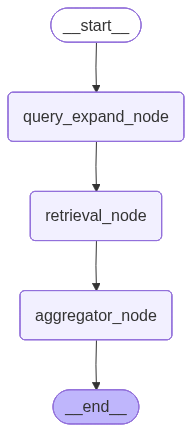

In [35]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
query = "Can I get tablets for me, for my kids and for my wife?"

In [37]:
inital_state = {
    "initial_query": query,  
}

In [47]:
result = graph.invoke(inital_state)

AttributeError: 'QueryExpandResponse' object has no attribute 'answer'